In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Beolvasás és magyar adatok kiválogatása
dataset = pd.read_csv("survey_results_public.csv")
dataset_hungary = dataset.loc[dataset["Country"] == "Hungary"]
del dataset
dataset_hungary["Country"].value_counts(dropna=False)

Country
Hungary    396
Name: count, dtype: int64

In [ ]:
# Üres értékek törlése
dataset_hungary.dropna(subset=["AISearchDevHaveWorkedWith"],inplace=True)

# Ahol egy sorban több adat van megadva, azt több sorba kell tárolni
dataset_hungary["AISearchDevHaveWorkedWith"] = dataset_hungary["AISearchDevHaveWorkedWith"].str.split(';')
dataset_hungary = dataset_hungary.explode(["AISearchDevHaveWorkedWith"]).reset_index(drop=True)

AISearchDevHaveWorkedWith
ChatGPT                      248
GitHub Copilot               130
Google Gemini                 63
Bing AI                       54
Visual Studio Intellicode     43
WolframAlpha                  23
Tabnine                       20
Codeium                       16
Phind                          8
Claude                         7
Perplexity AI                  6
OpenAI Codex                   5
Meta AI                        5
You.com                        5
Whispr AI                      4
Amazon Q                       3
Snyk Code                      2
Lightning AI                   1
AskCodi                        1
Cody                           1
Metaphor                       1
Name: count, dtype: int64

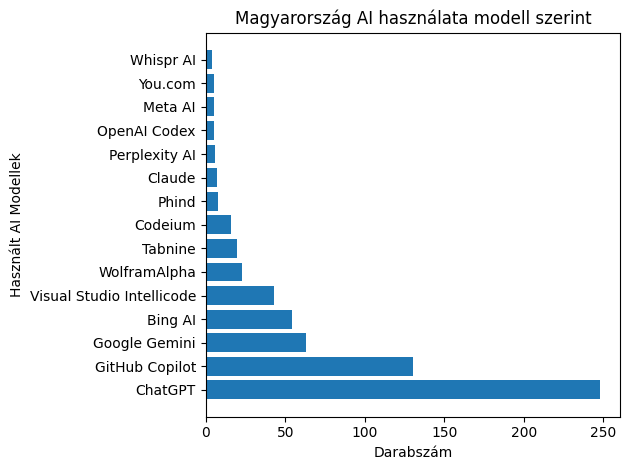

In [ ]:
# Tengelyek
ax = plt.subplot()

# 15 leghasználtabb nyelv
counts = dataset_hungary["AISearchDevHaveWorkedWith"].value_counts().head(15)

# a value_counts() visszad egy index és egy values értéket, jelenesetben a nyelveket és a darabszámokat
ai = counts.index
darabszam = counts.values

# Tengelyek megadása
ax.barh(ai,darabszam)

# Tengelyek elnevezése
ax.set_xlabel("Darabszám")
ax.set_ylabel("Használt AI Modellek")
ax.set_title("Magyarország AI használata modell szerint")


# tight_layout() elrendezi a vásznon az értékeket
plt.tight_layout()
plt.show()